# Joukowski Transform & Conformal Airfoils

## Conformal Mapping

A **conformal map** $w = f(z)$ is a holomorphic function that is locally angle-preserving. Conformal maps are a powerful tool for solving 2D potential flow problems: if $\phi$ satisfies Laplace's equation in one domain, then $\phi \circ f^{-1}$ satisfies it in the mapped domain.

## The Joukowski Transform

The **Joukowski (or Zhukovsky) transform** maps circles to airfoil-like shapes:
$$w = \frac{1}{2}\left(z + \frac{1}{z}\right)$$

Key observations:
- A **circle centered at the origin** with radius $r > 1$ maps to an **ellipse**
- A circle passing through $z = 1$ maps to a **flat plate** (degenerate case)
- A **circle offset from the origin** that passes through $z = 1$ maps to a **symmetric airfoil**
- Adding a vertical offset $\beta$ to the circle center produces a **cambered airfoil** with a pointed trailing edge

## Potential Flow Around an Airfoil

The complex potential for flow past a cylinder at angle of attack $\alpha$ is:
$$F(z) = U\left(z e^{-i\alpha} + \frac{R^2}{z} e^{i\alpha}\right) + \frac{i\Gamma}{2\pi} \log z$$

where $\Gamma$ is the **circulation**. The Kutta condition fixes $\Gamma$ so that the rear stagnation point coincides with the trailing edge, giving finite velocity there.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

### The Joukowski map and its inverse

We define the Joukowski map $J(z) = (z + 1/z)/2$ and visualize how it transforms circles into different shapes depending on the center and radius of the input circle.

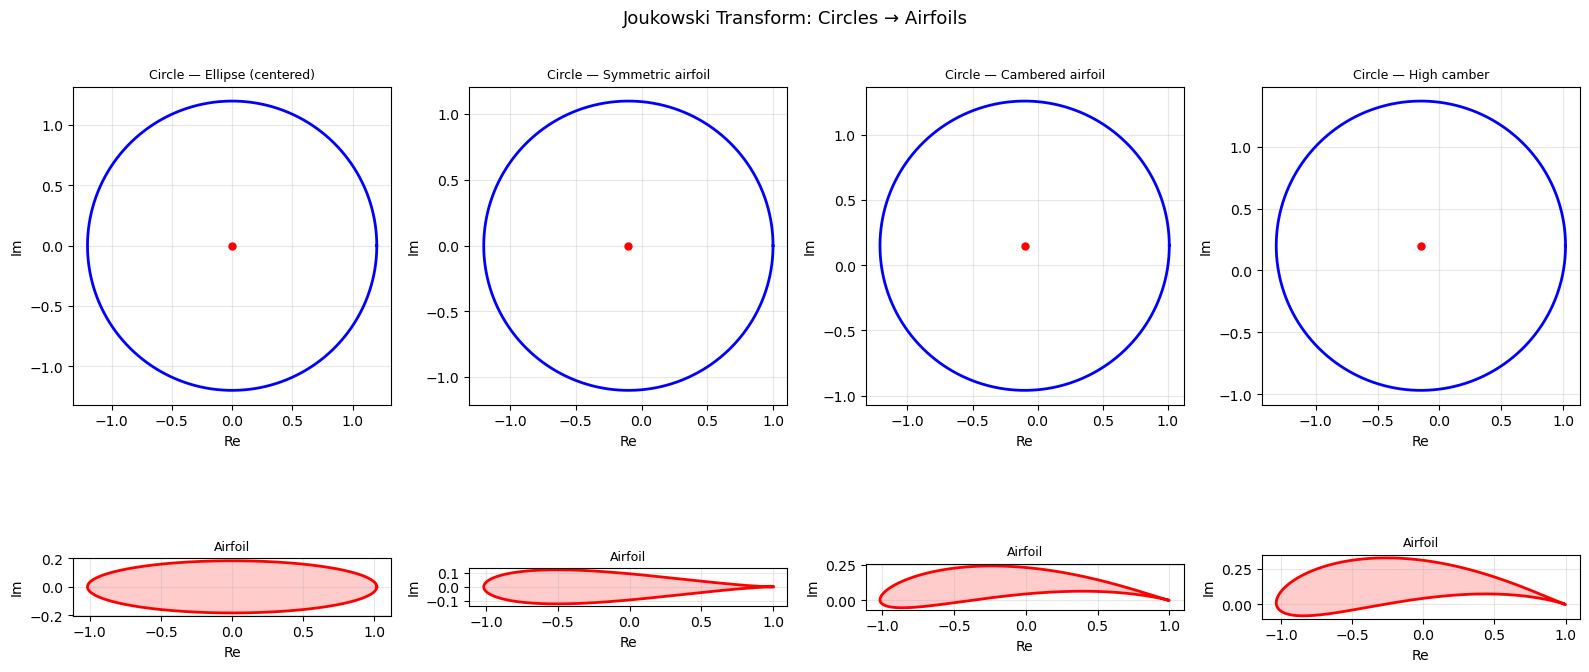

In [2]:
def joukowski(z):
    """Joukowski conformal map w = (z + 1/z) / 2."""
    with np.errstate(divide='ignore', invalid='ignore'):
        return 0.5 * (z + 1.0 / z)

def circle_points(center, radius, n=500):
    theta = np.linspace(0, 2*np.pi, n)
    return center + radius * np.exp(1j * theta)

# Show several cases
cases = [
    {'center': 0+0j, 'radius': 1.2, 'label': 'Ellipse (centered)'},
    {'center': -0.1+0j, 'radius': 1.1, 'label': 'Symmetric airfoil'},
    {'center': -0.1+0.15j, 'radius': np.abs(-0.1+0.15j - 1), 'label': 'Cambered airfoil'},
    {'center': -0.15+0.2j, 'radius': np.abs(-0.15+0.2j - 1), 'label': 'High camber'},
]
# Fix: radii must make circle pass through z=1 for proper airfoil
for c in cases[1:]:
    c['radius'] = abs(c['center'] - 1.0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, case in enumerate(cases):
    z_c = circle_points(case['center'], case['radius'])
    w_c = joukowski(z_c)

    axes[0, col].plot(z_c.real, z_c.imag, 'b-', lw=2)
    axes[0, col].plot(case['center'].real, case['center'].imag, 'r.', ms=10)
    axes[0, col].set_aspect('equal'); axes[0, col].set_title(f'Circle — {case["label"]}', fontsize=9)
    axes[0, col].set_xlabel('Re'); axes[0, col].set_ylabel('Im')
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(w_c.real, w_c.imag, 'r-', lw=2)
    axes[1, col].fill(w_c.real, w_c.imag, alpha=0.2, color='red')
    axes[1, col].set_aspect('equal'); axes[1, col].set_title(f'Airfoil', fontsize=9)
    axes[1, col].set_xlabel('Re'); axes[1, col].set_ylabel('Im')
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Joukowski Transform: Circles → Airfoils', fontsize=13)
plt.tight_layout(); plt.savefig('joukowski_shapes.png', dpi=100, bbox_inches='tight'); plt.show()

### Flow grid transformation

Conformal maps preserve the orthogonality of streamlines and equipotential lines. We visualize a **rectangular grid** in the $z$-plane (which represents uniform flow coordinates) and its image in the $w$-plane (physical flow coordinates).

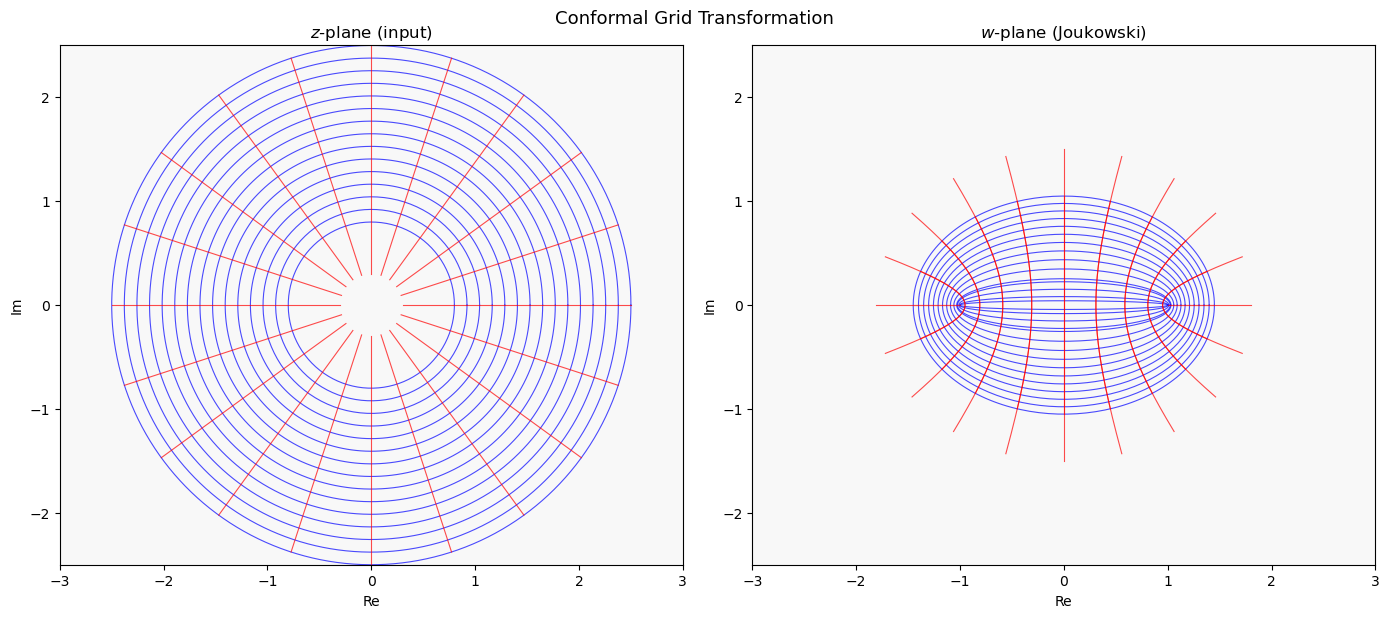

In [3]:
# Polar grid in z-plane (streamlines + circles)
n_r = 15
n_theta = 200
n_lines = 20

# Radial lines (streamlines)
r_vals = np.linspace(0.1, 2.5, 500)
theta_lines = np.linspace(0, 2*np.pi, n_lines, endpoint=False)

# Concentric circles (equipotentials)
theta_arr = np.linspace(0, 2*np.pi, n_theta)
r_circles = np.linspace(0.8, 2.5, n_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, transform, title in zip(axes, [lambda z: z, joukowski], ['$z$-plane (input)', '$w$-plane (Joukowski)']):
    ax.set_facecolor('#f8f8f8')
    # Concentric circles
    for r in r_circles:
        z = r * np.exp(1j * theta_arr)
        w = transform(z)
        ax.plot(w.real, w.imag, 'b-', lw=0.8, alpha=0.7)
    # Radial lines
    for th in theta_lines:
        z = r_vals * np.exp(1j * th)
        # avoid |z| < 0.3 to prevent singularity
        z = z[np.abs(z) > 0.3]
        w = transform(z)
        ax.plot(w.real, w.imag, 'r-', lw=0.8, alpha=0.7)
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3); ax.set_ylim(-2.5, 2.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')

plt.suptitle('Conformal Grid Transformation', fontsize=13)
plt.tight_layout(); plt.savefig('joukowski_flow.png', dpi=100, bbox_inches='tight'); plt.show()

### Potential flow around a Joukowski airfoil

Using the conformal equivalence, the **streamlines** around a Joukowski airfoil are obtained by mapping the known flow around a cylinder. The complex potential for uniform flow at angle $\alpha$ past a cylinder is:
$$F(z) = U\left(z e^{-i\alpha} + \frac{R^2 e^{i\alpha}}{z - z_c}\right) + \frac{i\Gamma}{2\pi}\log(z - z_c)$$

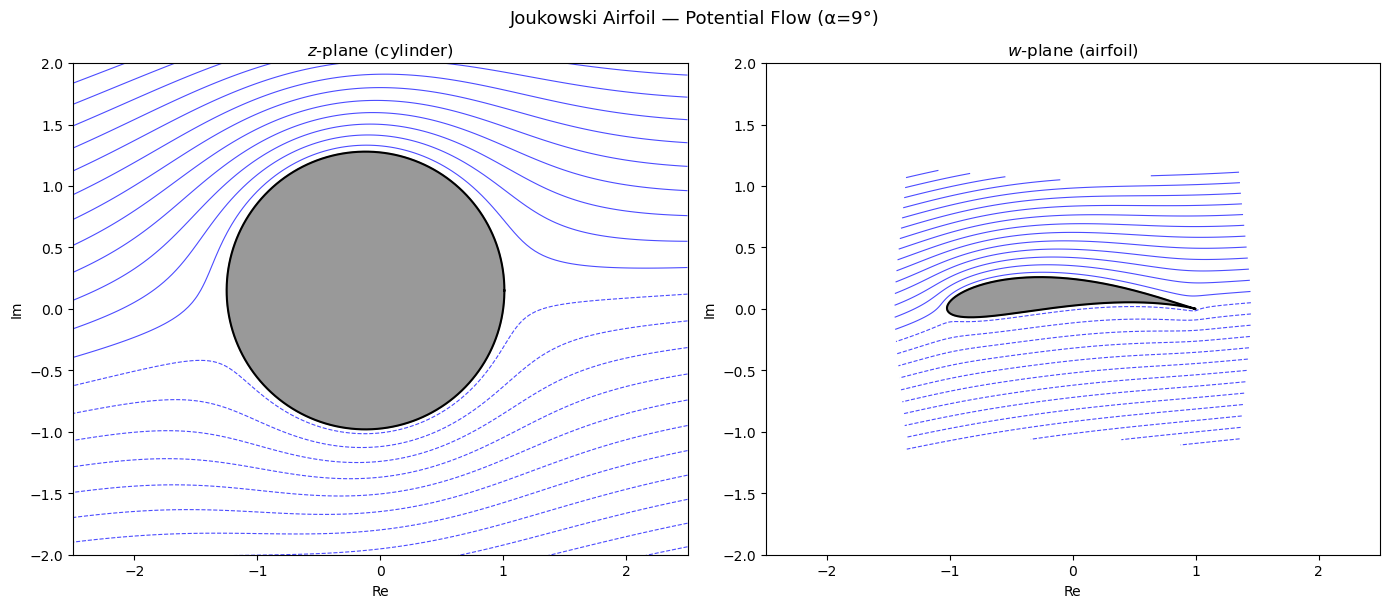

In [4]:
def complex_potential(z, z_center, R, alpha=0.1, U=1.0, Gamma=None):
    """Complex potential for flow past a cylinder."""
    zz = z - z_center
    if Gamma is None:
        # Kutta condition: Gamma = 4*pi*U*R*sin(alpha)
        Gamma = 4 * np.pi * U * R * np.sin(alpha)
    F = U * (zz * np.exp(-1j*alpha) + R**2 * np.exp(1j*alpha) / zz) + \
        1j * Gamma / (2*np.pi) * np.log(zz)
    return F

# Airfoil parameters
z_c_af = -0.12 + 0.15j
R_af = abs(z_c_af - 1.0)
alpha_af = 0.15  # angle of attack

# Grid in z-plane (outside the cylinder)
g = 150
xg = np.linspace(-2.5, 2.5, g)
Yg, Xg = np.meshgrid(xg, xg)
Z_grid = Xg + 1j * Yg

# Mask inside cylinder
inside = np.abs(Z_grid - z_c_af) < R_af

F_grid = complex_potential(Z_grid, z_c_af, R_af, alpha=alpha_af)
F_grid[inside] = np.nan
psi = F_grid.imag  # stream function

# Map to w-plane
W_grid = joukowski(Z_grid)

# Airfoil boundary
z_circle = circle_points(z_c_af, R_af)
w_airfoil = joukowski(z_circle)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, X, Y, title, bdry_x, bdry_y in [
    (axes[0], Xg, Yg, '$z$-plane (cylinder)', z_circle.real, z_circle.imag),
    (axes[1], W_grid.real, W_grid.imag, '$w$-plane (airfoil)', w_airfoil.real, w_airfoil.imag)
]:
    psi_clean = np.where(inside, np.nan, psi)
    ax.contour(X, Y, psi_clean, levels=np.linspace(psi_clean[~np.isnan(psi_clean)].min(),
                                                     psi_clean[~np.isnan(psi_clean)].max(), 30),
               colors='b', linewidths=0.8, alpha=0.7)
    ax.fill(bdry_x, bdry_y, color='gray', alpha=0.8, zorder=5)
    ax.plot(bdry_x, bdry_y, 'k-', lw=1.5, zorder=6)
    ax.set_aspect('equal'); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2, 2)
    ax.set_title(title, fontsize=12); ax.set_xlabel('Re'); ax.set_ylabel('Im')

plt.suptitle(f'Joukowski Airfoil — Potential Flow (α={np.degrees(alpha_af):.0f}°)', fontsize=13)
plt.tight_layout(); plt.savefig('joukowski_streamlines.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: vary airfoil shape and angle of attack

### Snippet

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 4, figsize=(14, 7))
    for col, case in enumerate(cases):
        z_c = circle_points(case['center'], case['radius'])
        w_c = joukowski(z_c)
        axes[0, col].plot(z_c.real, z_c.imag, 'b-', lw=2)
        axes[0, col].set_aspect('equal'); axes[0, col].set_title(case['label'], fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].plot(w_c.real, w_c.imag, 'r-', lw=2)
        axes[1, col].fill(w_c.real, w_c.imag, alpha=0.3, color='red')
        axes[1, col].set_aspect('equal'); axes[1, col].axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- The Joukowski transform $w = (z + 1/z)/2$ maps circles offset from the origin to smooth **airfoil profiles**.
- Conformal maps preserve angles and map solutions of Laplace's equation between domains.
- The **Kutta condition** (finite velocity at the trailing edge) fixes the circulation $\Gamma$ and lifts the degeneracy.
- The Joukowski family generates realistic airfoils whose lift is given by the **Kutta–Joukowski theorem**: $L = \rho U \Gamma$.

## Bibliography

- N. Joukowski, *Sur les contours portants en aéronautique*, Bulletin de l'IMA, 1910.
- L. M. Milne-Thomson, *Theoretical Aerodynamics*, Dover, 1973.
- L. V. Ahlfors, *Complex Analysis*, McGraw-Hill, 1979.